<a href="https://colab.research.google.com/github/crawford1273/ES2245/blob/main/Copy_of_ES2245_lab9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratory 9: Statistical and Spectral Analysis in Geophysics
**Course:** EARTHSC 2245: Introductory Data Analysis for Earth and Environmental Sciences

**Topics** Non-Parametric Tests, Time-Domain, and Frequency-Domain Analysis


**Objective:** Apply concepts from Lectures 21 and 22 to analyze geological and seismic data.
1. **Lecture 21 Focus:** Non-parametric statistics (Friedman, Spearman) and Time-domain analysis (Moving averages, Aliasing, Correlation).
2. **Lecture 22 Focus:** Frequency-domain analysis (FFT, PSD), Spectrograms, and digital filtering.

In [18]:
#Run this line once, you will have to reload lab, then you can comment this out
!pip install obspy

In [19]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, signal
import obspy
from obspy.clients.fdsn import Client

# Set plot style for the notebook
plt.rcParams['figure.figsize'] = [10, 6]
%matplotlib inline

## Task 1: Non-Parametric Comparisons (Friedman Test)
**Concept:** When data doesn't follow a normal distribution, we use the Friedman test to compare 3+ related samples.
**Scenario:** You have 5 rock samples. You measure their permeability ($mD$) under three different confining pressures (10MPa, 20MPa, 30MPa). Does pressure significantly change permeability?

In [20]:
import numpy as np
from scipy import stats

# Data: Rows are rock samples, Columns are pressure levels
perm_data = np.array([
    [15.2, 14.8, 13.9], # Sample 1
    [10.1, 9.5, 8.2],   # Sample 2
    [25.4, 24.1, 23.0], # Sample 3
    [5.5, 5.0, 4.1],    # Sample 4
    [18.9, 17.5, 16.2]  # Sample 5
])

# Perform Friedman Test
stat, p_val = stats.friedmanchisquare(perm_data[:, 0], perm_data[:, 1], perm_data[:, 2])

print(f"Friedman Statistic: {stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("Result: Pressure significantly changes permeability (p < 0.05).")
else:
    print("Result: Pressure does not significantly change permeability (p >= 0.05).")

Friedman Statistic: 10.0000
P-value: 0.0067
Result: Pressure significantly changes permeability (p < 0.05).


##Task 2: Spearman Rank Correlation

**Concept:** Use Spearman's $\rho$ to find monotonic relationships between variables that are not necessarily linear (e.g., Mineral concentration vs. Depth).

In [21]:
# Depth (m) and Gold Concentration (ppm)
depth = np.array([100, 200, 300, 400, 500, 600, 700, 800])
gold_ppm = np.array([0.2, 0.5, 1.1, 2.4, 5.1, 10.2, 11.5, 12.1])

# Calculate Spearman Rank Correlation
rho, p_val = stats.spearmanr(depth, gold_ppm)

print(f"Spearman correlation (rho): {rho:.4f}")
print(f"P-value: {p_val:.4f}")

Spearman correlation (rho): 1.0000
P-value: 0.0000


##Task 3: The Nyquist Frequency and Aliasing

**Concept:** Lecture 21 discusses Aliasing. If your sampling frequency ($f_s$) is less than twice the highest frequency in your signal ($2 \times f_{max}$), you get artifacts.

**Goal:** Create a 10 Hz sine wave. Sample it correctly (e.g., 50 Hz) and incorrectly (e.g., 12 Hz) to see aliasing.

The Nyquist frequency is 6.0 Hz. Since our signal is 10 Hz, we expect aliasing.


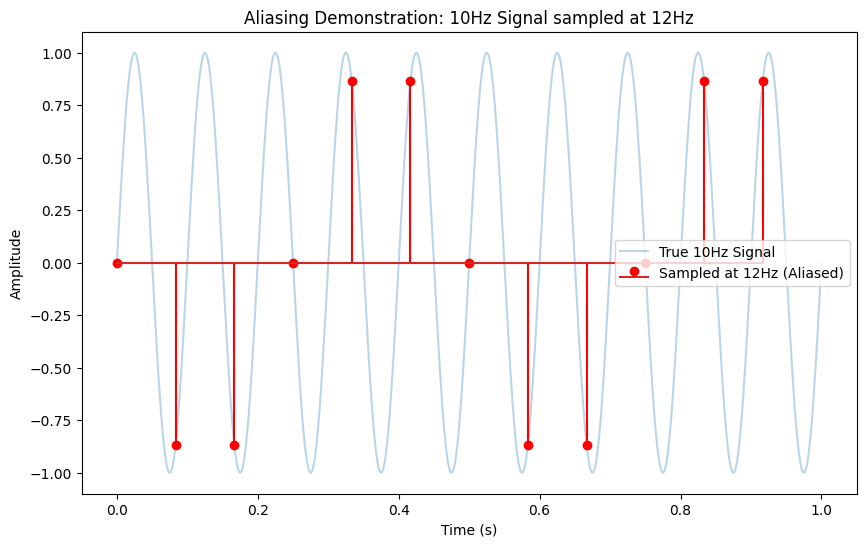

In [22]:
t_fine = np.linspace(0, 1, 1000)
f_signal = 10 # 10 Hz signal
y_true = np.sin(2 * np.pi * f_signal * t_fine)

# Low sampling rate (Aliasing!)
fs_low = 12
t_low = np.arange(0, 1, 1/fs_low)
y_low = np.sin(2 * np.pi * f_signal * t_low)

plt.plot(t_fine, y_true, label='True 10Hz Signal', alpha=0.3)
plt.stem(t_low, y_low, 'r', label='Sampled at 12Hz (Aliased)')

# 1. Calculate the Nyquist frequency for a 12Hz sampling rate.
nyquist = fs_low / 2
print(f"The Nyquist frequency is {nyquist} Hz. Since our signal is {f_signal} Hz, we expect aliasing.")

# 2. Add a title and labels to the plot.
plt.title("Aliasing Demonstration: 10Hz Signal sampled at 12Hz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

##Task 4: Cross-Correlation (Travel Time)

**Concept:** Cross-correlation identifies the time lag between two signals. In seismology, we use this to find the travel time of a wave between two sensors.

Detected Time Delay: 0.206 seconds


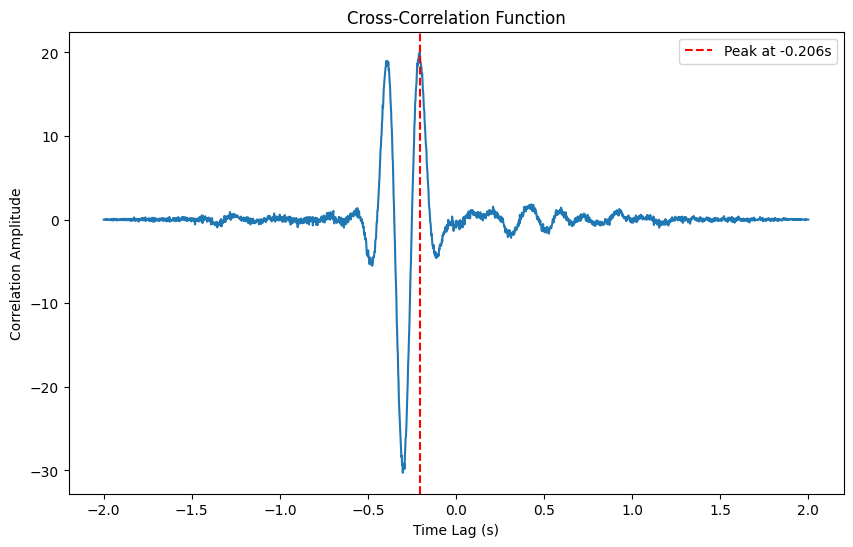

In [23]:
# Create a synthetic seismic pulse
t = np.linspace(0, 2, 1000)
def pulse(time, center):
    return np.exp(-(time-center)**2 / 0.01) * np.sin(2 * np.pi * 5 * time)

sensor1 = pulse(t, 0.5) + np.random.normal(0, 0.1, 1000)
sensor2 = pulse(t, 0.8) + np.random.normal(0, 0.1, 1000) # Delayed by 0.3s

# Calculate Cross-Correlation
correlation = np.correlate(sensor1, sensor2, mode='full')
lags = np.arange(-len(sensor1) + 1, len(sensor1))
best_lag_idx = np.argmax(correlation)

# Calculate time delay based on sampling interval
dt = t[1] - t[0]
time_delay = lags[best_lag_idx] * dt

print(f"Detected Time Delay: {abs(time_delay):.3f} seconds")

plt.plot(lags * dt, correlation)
plt.axvline(time_delay, color='r', linestyle='--', label=f'Peak at {time_delay:.3f}s')
plt.title("Cross-Correlation Function")
plt.xlabel("Time Lag (s)")
plt.ylabel("Correlation Amplitude")
plt.legend()
plt.show()

## Task 5: Frequency Domain - Power Spectral Density (PSD)
**Concept:** Lecture 22 explains that a Power Spectrum pulls apart "composite" signals to reveal hidden periodicities (like the 24-hour cycle vs. 365-day cycle). In seismology, we use PSDs to distinguish between seismic events and background "ambient noise."

/usr/local/lib/python3.12/dist-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)


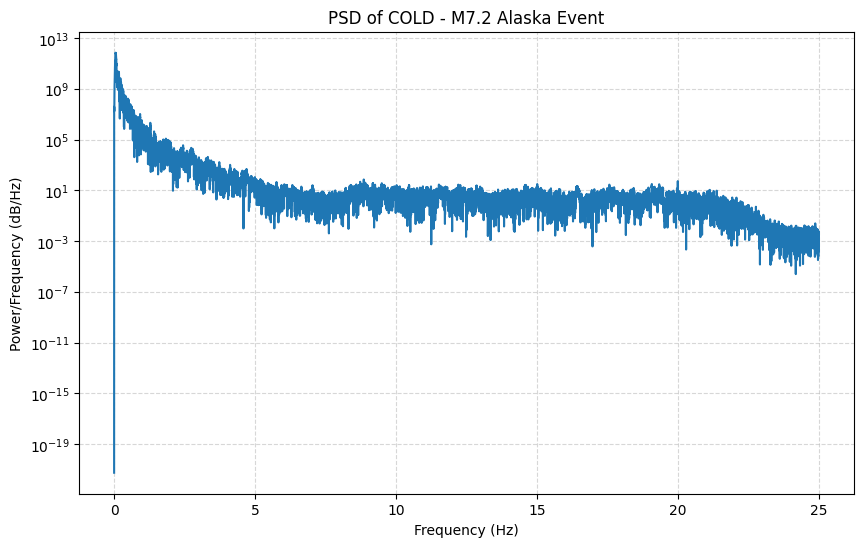

In [24]:
from scipy import signal

# Fetching data for a recent event using ObsPy
client = Client("IRIS")
starttime = obspy.UTCDateTime("2023-07-16T06:48:00") # M7.2 Alaska Event
st = client.get_waveforms("AK", "COLD", "", "BHZ", starttime, starttime + 600)
tr = st[0]

# Pre-processing
tr.detrend('linear')
tr.taper(0.05)

# 1. Use scipy.signal.periodogram to calculate the PSD
freqs, psd = signal.periodogram(tr.data, fs=tr.stats.sampling_rate)

# 2. Plot the result on a semilogy scale
plt.semilogy(freqs, psd)
plt.title(f"PSD of {tr.stats.station} - M7.2 Alaska Event")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power/Frequency (dB/Hz)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

## Task 6: Time-Frequency Analysis - Spectrograms
**Concept:** A Power Spectrum (PSD) tells you *what* frequencies exist in the data, but a **Spectrogram** tells you *when* those frequencies occur. This is critical for identifying the arrival of different seismic phases (P-waves vs. S-waves).

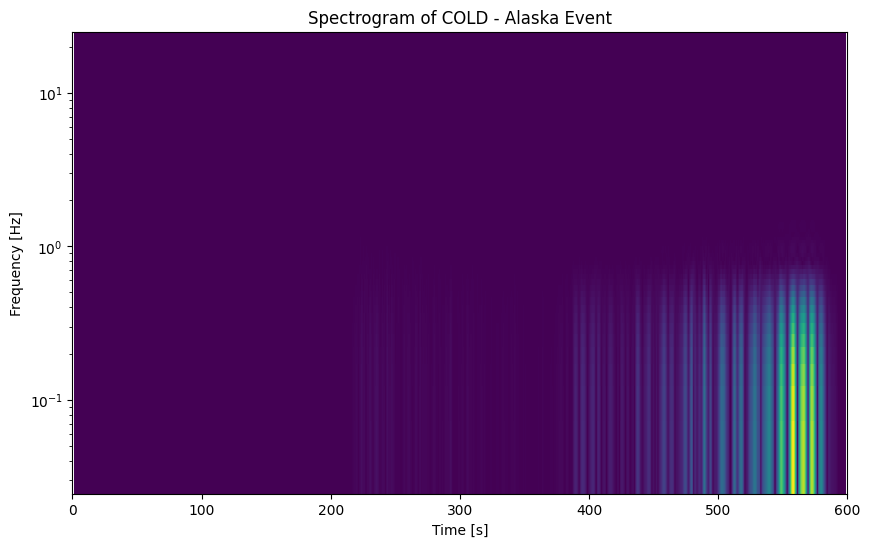

In [25]:
# Apply the built-in .spectrogram() method
# Use 'log=True' to handle the high dynamic range of seismic energy
tr.spectrogram(log=True, title=f"Spectrogram of {tr.stats.station} - Alaska Event")

##Task 7: Wavelet Transform

**Concept** A wavelet transform is roughly equivalent to a spectrogram, except analysis is performed in the time domain.

**Task:** Write all of the code to perform a wavelet transform on the trace from Tasks 5 and 6 and plot them. Perform two different wavelet transforms for different wavelet parameters (minimum and maximum frequencies

The resource found here shows how to do this in obspy: https://docs.obspy.org/archive/stable/tutorial/code_snippets/continuous_wavelet_transform.html

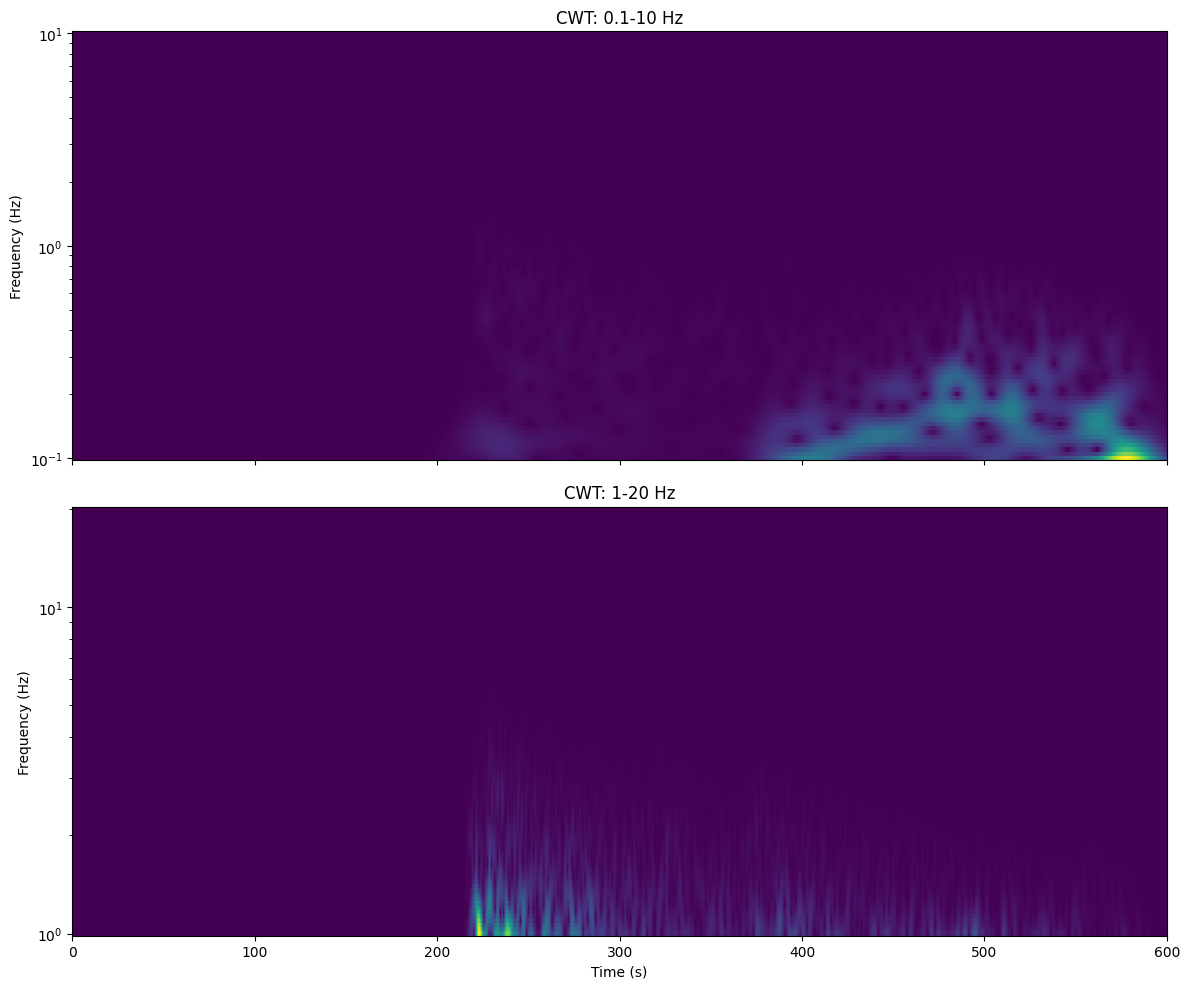

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import obspy
from obspy.imaging.cm import obspy_sequential
from obspy.signal.tf_misfit import cwt

# Parameters for the Continuous Wavelet Transform (CWT)
dt = tr.stats.delta
npts = tr.stats.npts
t = np.linspace(0, dt * npts, npts)

# Perform two different transforms with different frequency ranges
f_min1, f_max1 = 0.1, 10
f_min2, f_max2 = 1, 20

scalogram1 = cwt(tr.data, dt, 8, f_min1, f_max1)
scalogram2 = cwt(tr.data, dt, 8, f_min2, f_max2)

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot 1
x1, y1 = np.meshgrid(t, np.logspace(np.log10(f_min1), np.log10(f_max1), scalogram1.shape[0]))
im1 = ax1.pcolormesh(x1, y1, np.abs(scalogram1), cmap=obspy_sequential, shading='auto')
ax1.set_yscale('log')
ax1.set_ylabel("Frequency (Hz)")
ax1.set_title(f"CWT: {f_min1}-{f_max1} Hz")

# Plot 2
x2, y2 = np.meshgrid(t, np.logspace(np.log10(f_min2), np.log10(f_max2), scalogram2.shape[0]))
im2 = ax2.pcolormesh(x2, y2, np.abs(scalogram2), cmap=obspy_sequential, shading='auto')
ax2.set_yscale('log')
ax2.set_ylabel("Frequency (Hz)")
ax2.set_xlabel("Time (s)")
ax2.set_title(f"CWT: {f_min2}-{f_max2} Hz")

plt.tight_layout()
plt.show()

## Lab Questions for Submission

### Question 1: Power Spectra
**Answer:** The frequency domain is more useful because it decomposes a complex, noisy time-series signal into its constituent frequencies. While noise might obscure a signal in the time domain, the PSD concentrates the energy of a periodic signal into a specific frequency bin (a peak), making it much easier to identify the 'dominant period' regardless of high-frequency random noise.

### Question 2: Spectrograms
**Answer:**
* **Which plot better illustrates a signal whose frequency content changes over time?** The Spectrogram (Task 6), since it includes a time axis alongside frequency.
* **What does a vertical 'blast' represent?** In a seismogram, a vertical blast across many frequencies usually represents the impulsive arrival of a seismic phase (like the P-wave or S-wave), which contains a wide range of frequencies occurring simultaneously at that specific moment.

### Question 3: Wavelet Transforms
**Answer:** Wavelet transforms use finite, localized 'pulses' rather than infinite sine waves. This makes them superior for non-stationary signals like seismic 'jolts' because they can provide high time resolution for high-frequency events, accurately capturing the exact onset and duration of a short-lived transient signal without the 'averaging' effect inherent in a standard Windowed Fourier Transform.

### Question 4: Filtering
**Answer:** You would use a Low-Pass filter. Earth Tides have a very long period (~12 hours), which translates to an extremely low frequency. A low-pass filter allows these low-frequency deformations to pass through while blocking ('filtering out') the higher-frequency noise generated by earthquakes (typically >0.01 Hz) and traffic (>1 Hz).